# SMM Sensitivity Analysis — Moment–Parameter Jacobian

**Goal:** Before running SMM, learn which parameters actually move which moments.

**Steps executed here:**
1. Load the solver from `../solver/` — no code duplication
2. Solve at default parameters (baseline)
3. Perturb each free parameter ±10% and recompute all moments
4. Compute a numerical Jacobian (elasticity table)
5. Flag parameters with no responsive moment (|elasticity| < 0.1 everywhere)
6. Heatmap of the full Jacobian

> Sensitivity runs use a coarser grid (Nx=Np=60) and relaxed tolerances for speed.
> 26 params × 2 directions = 52 solves, roughly 2–5 min on a modern laptop.


## 1 · Packages and solver files

In [1]:
using LinearAlgebra, SparseArrays, Statistics, Random
using Distributions, FastGaussQuadrature, Interpolations
using Parameters, Printf
using Base.Threads

Random.seed!(42)

# Load every solver file from ../solver/ — notebook lives in notebooks/
const SOLVER_DIR = joinpath(@__DIR__, "..", "solver")

include(joinpath(SOLVER_DIR, "grids.jl"))
include(joinpath(SOLVER_DIR, "params.jl"))
include(joinpath(SOLVER_DIR, "unskilled.jl"))
include(joinpath(SOLVER_DIR, "skilled.jl"))
include(joinpath(SOLVER_DIR, "solver.jl"))
include(joinpath(SOLVER_DIR, "equilibrium.jl"))

println("Solver loaded  |  threads: ", Threads.nthreads())

Solver loaded  |  threads: 10


## 2 · Solver settings

In [2]:
# Tight settings for the single baseline solve
const SIM_BASELINE = SimParams(
    tol_inner=1e-8, tol_outer_U=1e-6, tol_outer_S=1e-5, tol_global=1e-3,
    maxit_inner=500, maxit_outer=300, maxit_global=50, conv_streak=2,
    use_anderson=true, anderson_m=1, anderson_reg=1e-10,
    damp_pstar_U=1.30, damp_pstar_S=0.05,
    verbose=1, verbose_stride=50,
)

# Relaxed settings for the 52 sensitivity solves (fast)
const SIM_FAST = SimParams(
    tol_inner=1e-6, tol_outer_U=1e-4, tol_outer_S=1e-4, tol_global=1e-2,
    maxit_inner=300, maxit_outer=200, maxit_global=30, conv_streak=2,
    use_anderson=true, anderson_m=1, anderson_reg=1e-10,
    damp_pstar_U=1.30, damp_pstar_S=0.05,
    verbose=0, verbose_stride=99999,
)

# Coarser grid for sensitivity solves
const SENS_NX = 60 ; const SENS_NP = 60
println("Settings ready.")

Settings ready.


## 3 · Default parameter dictionary

In [3]:
# Flat dictionary: ASCII keys map unambiguously to struct fields.
# Struct-qualified names (unsk_* / skl_*) disambiguate the two markets.
const DEFAULT_PARAMS = Dict{Symbol,Float64}(
    # CommonParams
    :r       => 0.05,
    :nu      => 0.05,
    :phi     => 0.20,
    :a_l     => 2.00,
    :b_l     => 5.00,
    :c       => 1.70,
    # RegimeParams
    :PU      => 0.70,
    :PS      => 1.85,
    :bU      => 0.01,
    :bT      => 0.28,
    :bS      => 0.02,
    :alpha_U => 1.00,
    :a_Gam   => 2.00,
    :b_Gam   => 5.00,
    # UnskilledParams
    :unsk_mu  => 0.74,
    :unsk_eta => 0.60,
    :unsk_k   => 0.25,
    :unsk_bet => 0.40,
    :unsk_lam => 0.08,
    # SkilledParams
    :skl_mu   => 0.80,
    :skl_eta  => 0.50,
    :skl_k    => 0.17,
    :skl_bet  => 0.32,
    :skl_xi   => 0.03,
    :skl_lam  => 0.07,
    :skl_sig  => 0.01,
)

# Ordered list of param keys (for iteration) with human-readable labels
const PARAM_SPECS = [
    (:r,       "discount rate r"),
    (:nu,      "demographic exit \u03bd"),
    (:phi,     "training completion \u03c6"),
    (:a_l,     "worker type shape a_\u2113"),
    (:b_l,     "worker type shape b_\u2113"),
    (:c,       "training cost c"),
    (:PU,      "unskilled productivity PU"),
    (:PS,      "skilled productivity PS"),
    (:bU,      "unskilled UI flow bU"),
    (:bT,      "training flow bT"),
    (:bS,      "skilled UI flow bS"),
    (:alpha_U, "damage shock shape \u03b1_U"),
    (:a_Gam,   "skilled offer shape a_\u0393"),
    (:b_Gam,   "skilled offer shape b_\u0393"),
    (:unsk_mu,  "unskilled matching eff \u03bc_U"),
    (:unsk_eta, "unskilled matching elas \u03b7_U"),
    (:unsk_k,   "unskilled vacancy cost k_U"),
    (:unsk_bet, "unskilled bargaining \u03b2_U"),
    (:unsk_lam, "unskilled damage rate \u03bb_U"),
    (:skl_mu,   "skilled matching eff \u03bc_S"),
    (:skl_eta,  "skilled matching elas \u03b7_S"),
    (:skl_k,    "skilled vacancy cost k_S"),
    (:skl_bet,  "skilled bargaining \u03b2_S"),
    (:skl_xi,   "skilled exog sep rate \u03be_S"),
    (:skl_lam,  "skilled quality shock \u03bb_S"),
    (:skl_sig,  "OJS flow cost \u03c3"),
]

const PARAM_KEYS   = first.(PARAM_SPECS)
const PARAM_LABELS = last.(PARAM_SPECS)
println("Parameters defined: ", length(PARAM_KEYS), " free params")

Parameters defined: 26 free params


## 4 · Rebuild all param structs from a flat dictionary

In [4]:
"""
    build_params(d) -> (CommonParams, RegimeParams, UnskilledParams, SkilledParams)

Reconstructs all four parameter structs from the flat dict `d`.
Struct keyword names use the original Unicode field names from params.jl.
"""
function build_params(d::Dict{Symbol,Float64})
    common = CommonParams(
        r   = d[:r],
        ν   = d[:nu],
        φ   = d[:phi],
        a_ℓ = d[:a_l],
        b_ℓ = d[:b_l],
        c   = d[:c],
    )
    regime = RegimeParams(
        PU  = d[:PU],
        PS  = d[:PS],
        bU  = d[:bU],
        bT  = d[:bT],
        bS  = d[:bS],
        α_U = d[:alpha_U],
        a_Γ = d[:a_Gam],
        b_Γ = d[:b_Gam],
    )
    unsk = UnskilledParams(
        μ = d[:unsk_mu],
        η = d[:unsk_eta],
        k  = d[:unsk_k],
        β = d[:unsk_bet],
        λ = d[:unsk_lam],
    )
    skl = SkilledParams(
        μ = d[:skl_mu],
        η = d[:skl_eta],
        k  = d[:skl_k],
        β = d[:skl_bet],
        ξ = d[:skl_xi],
        λ = d[:skl_lam],
        σ = d[:skl_sig],
    )
    return common, regime, unsk, skl
end
println("build_params defined.")

build_params defined.


## 5 · Moment computation

In [5]:
"""
    compute_moments(obj, model) -> NamedTuple

Compute 28 SMM candidate moments from a solved equilibrium object.

New moments vs. original 19
────────────────────────────
  p25_wage_U / p10_wage_U   lower-tail unskilled wages  → identifies α_U
  p25_wage_S / p10_wage_S   lower-tail skilled wages    → identifies b_S
  skl_accept                P(accept | contact, unskilled unemp) → identifies b_S
"""
function compute_moments(obj, model)
    cp  = model.common
    up  = model.unsk_par
    sp  = model.skl_par
    rp  = model.regime
    pre = model.skl_pre
    uc  = model.unsk_cache
    sc  = model.skl_cache
    wx  = obj.wx
    Nx  = obj.Nx

    # ── Labour market stocks ──────────────────────────────────────────────
    ur_total       = obj.ur_total
    ur_U           = obj.ur_U
    ur_S           = obj.ur_S
    skilled_share  = obj.agg_mS / max(obj.total_pop, 1e-14)
    training_share = obj.agg_t  / max(obj.total_pop, 1e-14)

    # ── Tightness ─────────────────────────────────────────────────────────
    theta_U = obj.thetaU
    theta_S = obj.thetaS

    # ── Job-finding rates (contact rates κ = θ·q(θ)) ─────────────────────
    jfr_U = jobfinding_rate(theta_U, up.μ, up.η)
    jfr_S = jobfinding_rate(theta_S, sp.μ, sp.η)   # κ_S

    # ── Separation rates (employment-weighted average hazard) ─────────────
    # Unskilled: G_z(p) = p^{α_U}, so δ_U(x) = λ_U * pstar_U(x)^{α_U}
    δ_U_x  = up.λ .* (uc.pstar .^ rp.α_U)
    eU_vec = obj.eU_vec
    tot_eU = max(dot(eU_vec, wx), 1e-14)
    sep_rate_U = dot(δ_U_x .* eU_vec, wx) / tot_eU

    # Skilled: δ_S(x) = ξ_S + λ_S · Γ(pstar_S(x))
    pg_S = model.skl_grids.p
    Γ_pstar_S = [
        pre.Γvals[clamp(pcut_index(pg_S, clamp01(sc.pstar[ix])), 1, length(pg_S))]
        for ix in 1:Nx
    ]
    δ_S_x  = sp.ξ .+ sp.λ .* Γ_pstar_S
    eS_tot = obj.eS_tot
    tot_eS = max(dot(eS_tot, wx), 1e-14)
    sep_rate_S = dot(δ_S_x .* eS_tot, wx) / tot_eS

    # ── Training rate = outflow from training / untrained-unemp stock ─────
    # Steady state: φ·t(x) + ν·t(x) = τ(x)·u_U(x)
    # => training_rate = (φ + ν) · agg_t / agg_uU
    training_rate = (cp.φ + cp.ν) * obj.agg_t / max(obj.agg_uU, 1e-14)

    # ── Wages from pre-computed densities ─────────────────────────────────
    wmid = obj.wmid
    bw   = wmid[2] - wmid[1]
    dU   = obj.dens_U
    dS   = obj.dens_S

    mean_wage_U = dot(wmid, dU) * bw
    mean_wage_S = dot(wmid, dS) * bw

    function wage_percentile(wmid, dens, bw, q)
        cdf = cumsum(dens .* bw)
        idx = searchsortedfirst(cdf, q)
        return wmid[clamp(idx, 1, length(wmid))]
    end

    p50_wage_U   = wage_percentile(wmid, dU, bw, 0.50)
    p50_wage_S   = wage_percentile(wmid, dS, bw, 0.50)
    mean_log_wage_U = dot(log.(max.(wmid, 1e-14)), dU) * bw
    mean_log_wage_S = dot(log.(max.(wmid, 1e-14)), dS) * bw
    wage_premium    = mean_log_wage_S / max(mean_log_wage_U, 1e-14)

    var_U     = dot(wmid .^ 2, dU) * bw - mean_wage_U^2
    var_S     = dot(wmid .^ 2, dS) * bw - mean_wage_S^2
    wage_sd_U = sqrt(max(var_U, 0.0))
    wage_sd_S = sqrt(max(var_S, 0.0))

    # ── Lower-tail wage percentiles ────────────────────────────────────────
    # p25/p10 of each sector's wage distribution.
    # Unskilled lower tail identifies α_U: the shape parameter of G_z(p)=p^{α_U}
    #   determines how much mass is near p* vs the top, controlling left-skew of w_U.
    # Skilled lower tail identifies b_S: higher b_S raises p_S* (the wage floor),
    #   shifting p10/p25 up independently of mean_wage_S and wage_sd_S.
    p25_wage_U = wage_percentile(wmid, dU, bw, 0.25)
    p10_wage_U = wage_percentile(wmid, dU, bw, 0.10)
    p25_wage_S = wage_percentile(wmid, dS, bw, 0.25)
    p10_wage_S = wage_percentile(wmid, dS, bw, 0.10)

    # ── Skilled acceptance probability ─────────────────────────────────────
    # P(offer accepted | contact) for a skilled unemployed worker, averaged over
    # x with equal weights (wx sums to 1).
    # = mean_x [ 1 - Γ(p_S*(x)) ]
    # Identifies b_S independently of θ_S: higher b_S → higher p_S* → lower
    # acceptance probability, even holding jfr_S (the contact rate) fixed.
    # Together with jfr_S, this pins the actual hire rate f_S·(1-Γ(p_S*)).
    skl_accept = dot(1.0 .- Γ_pstar_S, wx)


    # ── Employment-distribution moments over worker type x ────────────────
    # Second and third CENTRAL moments of the type distribution among
    # employed unskilled (e_U) and skilled (e_S) workers.
    # These identify a_ℓ and b_ℓ: the Beta(a_ℓ, b_ℓ) prior on x shapes the
    # type distribution in employment after equilibrium selection.
    # Variance captures the spread (related to a_ℓ + b_ℓ, the concentration),
    # third central moment captures asymmetry (related to a_ℓ vs b_ℓ skew).
    # NOTE: verify that obj.xgrid is the correct field name in your equilibrium object.
    xg = obj.xg   # x-grid, length Nx

    eU_mass   = eU_vec .* wx
    tot_eU_x  = max(sum(eU_mass), 1e-14)
    μ_eU      = dot(xg, eU_mass) / tot_eU_x
    emp_var_U = dot((xg .- μ_eU).^2, eU_mass) / tot_eU_x
    emp_cm3_U = dot((xg .- μ_eU).^3, eU_mass) / tot_eU_x

    eS_mass   = eS_tot .* wx
    tot_eS_x  = max(sum(eS_mass), 1e-14)
    μ_eS      = dot(xg, eS_mass) / tot_eS_x
    emp_var_S = dot((xg .- μ_eS).^2, eS_mass) / tot_eS_x
    emp_cm3_S = dot((xg .- μ_eS).^3, eS_mass) / tot_eS_x
    return (
        ur_total       = ur_total,
        ur_U           = ur_U,
        ur_S           = ur_S,
        skilled_share  = skilled_share,
        training_share = training_share,
        jfr_U          = jfr_U,
        sep_rate_U     = sep_rate_U,
        jfr_S          = jfr_S,
        sep_rate_S     = sep_rate_S,
        training_rate  = training_rate,
        mean_wage_U    = mean_wage_U,
        mean_wage_S    = mean_wage_S,
        p50_wage_U     = p50_wage_U,
        p50_wage_S     = p50_wage_S,
        wage_premium   = wage_premium,
        wage_sd_U      = wage_sd_U,
        wage_sd_S      = wage_sd_S,
        theta_U        = theta_U,
        theta_S        = theta_S,
        # ── New identification moments ────────────────────────────────────
        p25_wage_U     = p25_wage_U,
        p10_wage_U     = p10_wage_U,
        p25_wage_S     = p25_wage_S,
        p10_wage_S     = p10_wage_S,
        skl_accept     = skl_accept,
        # ── Employment type-distribution moments → a_ℓ, b_ℓ ─────────────────
        emp_var_U      = emp_var_U,
        emp_cm3_U      = emp_cm3_U,
        emp_var_S      = emp_var_S,
        emp_cm3_S      = emp_cm3_S,
    )
end
println("compute_moments defined  (28 moments).")


compute_moments defined  (28 moments).


## 6 · run_at_params helper

In [6]:
"""
    run_at_params(d; sim, Nx, Np_U, Np_S) -> (moments, converged::Bool)

Build structs from dict `d`, solve, return moments and a convergence flag.
"""
function run_at_params(d;
                        sim  = SIM_FAST,
                        Nx   = SENS_NX,
                        Np_U = SENS_NP,
                        Np_S = SENS_NP)
    cp, rp, up, sp = build_params(d)
    model, result  = solve_model(cp, rp, up, sp, sim; Nx=Nx, Np_U=Np_U, Np_S=Np_S)
    result.ok || @warn "Model did not fully converge"
    obj = compute_equilibrium_objects(model)
    m   = compute_moments(obj, model)
    return m, result.ok
end
println("run_at_params defined.")

run_at_params defined.


## 7 · Baseline solve at default parameters

In [7]:
println("Solving baseline (full resolution, tight tolerances)...")
@time global m_base, ok_base = run_at_params(DEFAULT_PARAMS;
                                               sim  = SIM_BASELINE,
                                               Nx   = 200,
                                               Np_U = 200,
                                               Np_S = 200)
println("\nBaseline converged: ", ok_base)

Solving baseline (full resolution, tight tolerances)...
[global it=1]  maxΔ=3.868e+00  (ΔUS=3.868e+00  ΔmS=1.638e+00)  θU=0.6722  θS=1.2702
[global]  converged it=6  d=3.609e-04
  6.507894 seconds (43.42 M allocations: 1.232 GiB, 1.66% gc time, 46.26% compilation time)

Baseline converged: true


## 8 · Baseline moments

In [8]:
println()
@printf("%-20s  %10s\n", "Moment", "Baseline")
println("-" ^ 34)
for (k, v) in pairs(m_base)
    @printf("%-20s  %10.5f\n", string(k), v)
end


Moment                  Baseline
----------------------------------
ur_total                 0.10178
ur_U                     0.13505
ur_S                     0.07247
skilled_share            0.53169
training_share           0.13292
jfr_U                    0.45662
sep_rate_U               0.05124
jfr_S                    1.05534
sep_rate_S               0.03098
training_rate            0.52542
mean_wage_U              0.10486
mean_wage_S              0.15880
p50_wage_U               0.05887
p50_wage_S               0.15187
wage_premium          -195014888339895.81250
wage_sd_U                0.08636
wage_sd_S                0.07253
theta_U                  0.29910
theta_S                  1.74023
p25_wage_U               0.03741
p10_wage_U               0.03026
p25_wage_S               0.10895
p10_wage_S               0.08033
skl_accept               0.93500
emp_var_U                0.02711
emp_cm3_U                0.00475
emp_var_S                0.02030
emp_cm3_S                0.0

## 9 · Sensitivity loop

Perturbation rule:
- **Relative:** `v₀ ± 10%` when `|v₀| > 10⁻⁸`
- **Absolute:** `v₀ ± 0.05` for zero-valued parameters (e.g. `bU = 0`)
- Minus-side is floored at `10⁻⁸` to keep all params strictly positive


In [9]:
const DELTA     = 0.10    # relative step size (10%)
const DELTA_ABS = 0.05    # absolute step for zero-valued params

moment_keys = propertynames(m_base)
n_moments   = length(moment_keys)
n_params    = length(PARAM_KEYS)

# Pre-allocate result storage
moments_plus  = Vector{Any}(undef, n_params)
moments_minus = Vector{Any}(undef, n_params)
conv_plus     = falses(n_params)
conv_minus    = falses(n_params)
step_used     = zeros(n_params)

println("\nSensitivity loop: ", n_params, " params x 2 directions")
println("=" ^ 62)

for (i, pkey) in enumerate(PARAM_KEYS)
    v0   = DEFAULT_PARAMS[pkey]
    step = abs(v0) > 1e-8 ? DELTA * abs(v0) : DELTA_ABS
    step_used[i] = step

    @printf("[%2d/%2d]  %-28s  v0=%7.4f  step=%6.4f", i, n_params, string(pkey), v0, step)

    d_plus        = copy(DEFAULT_PARAMS)
    d_plus[pkey]  = v0 + step
    mp, cp_ok     = run_at_params(d_plus)
    moments_plus[i]  = mp
    conv_plus[i]     = cp_ok

    d_minus       = copy(DEFAULT_PARAMS)
    d_minus[pkey] = max(v0 - step, 1e-8)
    mm, cm_ok     = run_at_params(d_minus)
    moments_minus[i] = mm
    conv_minus[i]    = cm_ok

    println("  ", (cp_ok && cm_ok) ? "ok" : "WARN")
end
println("\nSensitivity loop complete.")


Sensitivity loop: 26 params x 2 directions
[ 1/26]  r                             v0= 0.0500  step=0.0050  ok
[ 2/26]  nu                            v0= 0.0500  step=0.0050  ok
[ 3/26]  phi                           v0= 0.2000  step=0.0200  ok
[ 4/26]  a_l                           v0= 2.0000  step=0.2000  ok
[ 5/26]  b_l                           v0= 5.0000  step=0.5000  ok
[ 6/26]  c                             v0= 1.7000  step=0.1700  ok
[ 7/26]  PU                            v0= 0.7000  step=0.0700  ok
[ 8/26]  PS                            v0= 1.8500  step=0.1850  ok
[ 9/26]  bU                            v0= 0.0100  step=0.0010  ok
[10/26]  bT                            v0= 0.2800  step=0.0280  ok
[11/26]  bS                            v0= 0.0200  step=0.0020  ok
[12/26]  alpha_U                       v0= 1.0000  step=0.1000

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:13


  WARN
[13/26]  a_Gam                         v0= 2.0000  step=0.2000  ok
[14/26]  b_Gam                         v0= 5.0000  step=0.5000  ok
[15/26]  unsk_mu                       v0= 0.7400  step=0.0740  ok
[16/26]  unsk_eta                      v0= 0.6000  step=0.0600  ok
[17/26]  unsk_k                        v0= 0.2500  step=0.0250  ok
[18/26]  unsk_bet                      v0= 0.4000  step=0.0400  ok
[19/26]  unsk_lam                      v0= 0.0800  step=0.0080  ok
[20/26]  skl_mu                        v0= 0.8000  step=0.0800  ok
[21/26]  skl_eta                       v0= 0.5000  step=0.0500

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:13


  WARN
[22/26]  skl_k                         v0= 0.1700  step=0.0170  ok
[23/26]  skl_bet                       v0= 0.3200  step=0.0320  ok
[24/26]  skl_xi                        v0= 0.0300  step=0.0030

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:13


  WARN
[25/26]  skl_lam                       v0= 0.0700  step=0.0070

┌ Warning: Model did not fully converge
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:13


  WARN
[26/26]  skl_sig                       v0= 0.0100  step=0.0010  ok

Sensitivity loop complete.


## 10 · Build elasticity matrix

In [10]:
# Central-difference elasticity:
#   e_{j,i} = [(m_j(v+) - m_j(v-)) / (2 * step_i)] * (v_i / m_j_base)
# For zero-valued params: semi-elasticity (drop the v_i / m_j_base factor).
# For near-zero moments: fall back to absolute change.

E = zeros(n_moments, n_params)

for (i, pkey) in enumerate(PARAM_KEYS)
    v0   = DEFAULT_PARAMS[pkey]
    step = step_used[i]

    for (j, mkey) in enumerate(moment_keys)
        m_plus_j  = getfield(moments_plus[i],  mkey)
        m_minus_j = getfield(moments_minus[i], mkey)
        m_base_j  = getfield(m_base, mkey)

        dm = (m_plus_j - m_minus_j) / (2.0 * step)

        if abs(m_base_j) > 1e-6
            # standard elasticity when v0 != 0, semi-elasticity otherwise
            scale    = abs(v0) > 1e-8 ? v0 / m_base_j : 1.0 / m_base_j
            E[j, i]  = dm * scale
        else
            E[j, i]  = dm    # absolute change when moment itself is ~ 0
        end
    end
end

println("Jacobian computed: ", n_moments, " x ", n_params)

Jacobian computed: 28 x 26


## 11 · Full elasticity table

`*` marks |elasticity| ≥ 0.1 — informative cells for identification.

In [11]:
# Short param abbreviations for the column header
p_abbr = [
    "r", "nu", "phi", "a_l", "b_l", "c",
    "PU", "PS", "bU", "bT", "bS", "aU", "aG", "bG",
    "mu_U", "et_U", "k_U", "be_U", "la_U",
    "mu_S", "et_S", "k_S", "be_S", "xi_S", "la_S", "si_S",
]

COL = 7   # column width

# header
print(rpad("Moment", 16))
for ab in p_abbr ; print(lpad(ab, COL)) ; end
println()
println("-" ^ (16 + COL * n_params))

# rows
for (j, mn) in enumerate(moment_keys)
    print(rpad(string(mn), 16))
    for i in 1:n_params
        e = E[j, i]
        @printf("%s%6.2f", abs(e) >= 0.1 ? "*" : " ", e)
    end
    println()
end
println()
println("* = |elast| >= 0.1")

Moment                r     nu    phi    a_l    b_l      c     PU     PS     bU     bT     bS     aU     aG     bG   mu_U   et_U    k_U   be_U   la_U   mu_S   et_S    k_S   be_S   xi_S   la_S   si_S
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ur_total        *  0.16*  0.63*  0.12* -2.30*  0.40*  0.30*  0.60* -0.57*  0.18* -0.12  -0.09   0.02  -0.09   0.07* -0.40* -0.23   0.07*  0.34   0.10* -0.44*  0.10*  0.28*  0.16*  0.23   0.01  -0.00
ur_U            *  0.17*  0.39*  0.21* -0.73*  0.41*  0.32* -0.99*  0.57*  0.30   0.03* -0.16  -0.04*  0.43* -0.49* -0.86* -0.51*  0.21*  0.56*  0.26*  0.13  -0.01   0.06  -0.09   0.10   0.01   0.00
ur_S              -0.03*  0.57  -0.09*  4.98*  0.42* -0.29*  0.80* -1.24   0.01*  0.30*  0.18  -0.09* -0.55*  0.56  -0.07* -0.10*  0.11* -0.11   0.09* -1.15*  0.29*  0.45*  0.77*  0.28   0.01  -0.01
skill

## 12 · Identification flags — max |elasticity| per parameter

Parameters with **max |elasticity| < 0.1** across *all* moments are weakly identified.
Either add a targeted moment or calibrate externally.

In [12]:
println()
@printf("%-32s  %9s  %-18s  %s\n", "Parameter", "Max|elas|", "Best moment", "Flag")
println("-" ^ 76)

for (i, pkey) in enumerate(PARAM_KEYS)
    col      = abs.(E[:, i])
    max_abs  = maximum(col)
    best_j   = argmax(col)
    best_mom = string(moment_keys[best_j])
    flag     = max_abs < 0.1 ? ">>> WEAKLY IDENTIFIED" : ""
    lab      = PARAM_LABELS[i]
    @printf("%-32s  %9.4f  %-18s  %s\n", lab, max_abs, best_mom, flag)
end

println()
println("Weakly identified: no moment has |elasticity| >= 0.1.")
println("Action: add a targeted moment or fix the parameter externally.")


Parameter                         Max|elas|  Best moment         Flag
----------------------------------------------------------------------------
discount rate r                      0.6118  training_rate       
demographic exit ν                   0.8751  p25_wage_U          
training completion φ                1.1127  p25_wage_U          
worker type shape a_ℓ               27.6890  p10_wage_S          
worker type shape b_ℓ                1.4480  theta_U             
training cost c                      2.2134  p50_wage_U          
unskilled productivity PU           10.3789  p50_wage_U          
skilled productivity PS              7.3422  p50_wage_U          
unskilled UI flow bU                 0.7740  p10_wage_U          
training flow bT                     1.7083  training_rate       
skilled UI flow bS                   0.6084  training_rate       
damage shock shape α_U               0.7096  p25_wage_U          
skilled offer shape a_Γ              3.1237  emp_cm3_U      

## 13 · Most responsive parameter per moment

In [13]:
println()
@printf("%-20s  %9s  %-32s\n", "Moment", "Max|elas|", "Most responsive param")
println("-" ^ 65)

for (j, mn) in enumerate(moment_keys)
    row     = abs.(E[j, :])
    max_abs = maximum(row)
    best_p  = PARAM_LABELS[argmax(row)]
    @printf("%-20s  %9.4f  %-32s\n", string(mn), max_abs, best_p)
end


Moment                Max|elas|  Most responsive param           
-----------------------------------------------------------------
ur_total                 2.2980  worker type shape a_ℓ           
ur_U                     0.9948  unskilled productivity PU       
ur_S                     4.9799  worker type shape a_ℓ           
skilled_share            5.0088  worker type shape a_ℓ           
training_share           5.0088  worker type shape a_ℓ           
jfr_U                    3.3077  unskilled productivity PU       
sep_rate_U               0.9145  unskilled damage rate λ_U       
jfr_S                    1.2447  skilled matching eff μ_S        
sep_rate_S               4.9707  worker type shape a_ℓ           
training_rate            5.5077  worker type shape a_ℓ           
mean_wage_U              3.4871  unskilled productivity PU       
mean_wage_S              5.1796  worker type shape a_ℓ           
p50_wage_U              10.3789  unskilled productivity PU       
p50_wage_

## 14 · Heatmap of the Jacobian

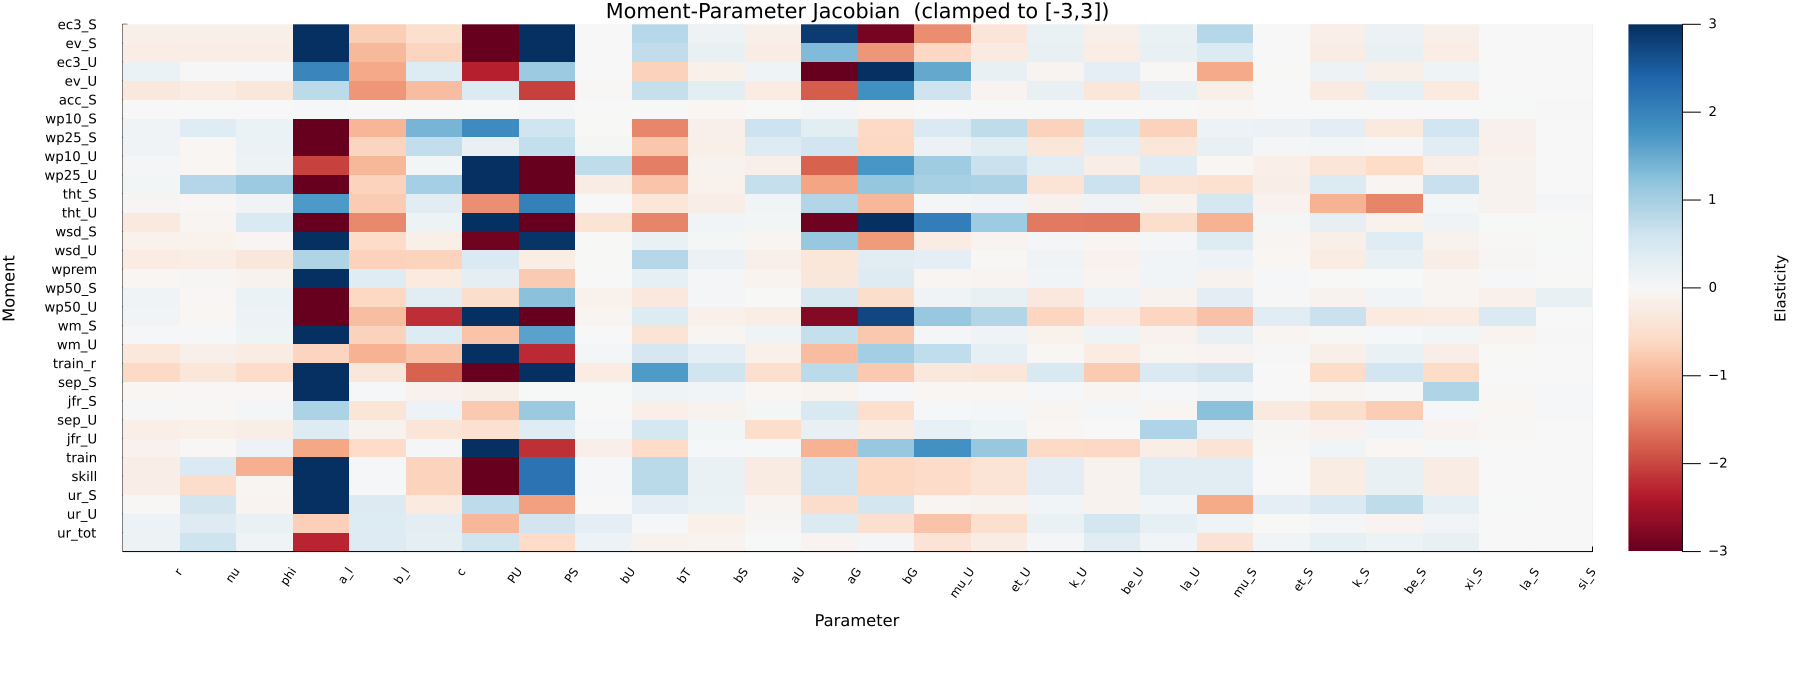

In [14]:
using Plots

# Short axis labels  (28 moments, rows of E)
m_short = [
    "ur_tot","ur_U","ur_S","skill","train",          # stocks
    "jfr_U","sep_U","jfr_S","sep_S","train_r",       # flows
    "wm_U","wm_S","wp50_U","wp50_S","wprem",          # wages (central)
    "wsd_U","wsd_S",                                  # wage dispersion
    "tht_U","tht_S",                                  # tightness
    "wp25_U","wp10_U",                                # unskilled lower tail  → α_U
    "wp25_S","wp10_S",                                # skilled lower tail    → b_S
    "acc_S",                                  # acceptance prob      → b_S
    # Employment type-distribution moments  → a_ℓ, b_ℓ
    "ev_U","ec3_U",                               # e_U variance, 3rd central moment
    "ev_S","ec3_S",                               # e_S variance, 3rd central moment
]

E_clamp = clamp.(E, -3.0, 3.0)

hm = heatmap(
    p_abbr, m_short, E_clamp;
    color           = :RdBu,
    clim            = (-3, 3),
    title           = "Moment-Parameter Jacobian  (clamped to [-3,3])",
    xlabel          = "Parameter",
    ylabel          = "Moment",
    xrotation       = 55,
    xticks          = (1:length(p_abbr), p_abbr),
    xtickfontsize   = 8,
    yticks          = (1:length(m_short), m_short),
    ytickfontsize   = 9,
    size            = (1800, 680),
    left_margin     = 8Plots.mm,
    bottom_margin   = 22Plots.mm,
    colorbar_title  = "Elasticity",
)

display(hm)


## 15 · Top-3 most responsive moments per parameter

Use these pairings to assign non-zero weights in `default_targets()` before the next SMM run.

In [15]:
println()
@printf("%-32s  %-18s  %-18s  %-18s\n", "Parameter", "1st moment", "2nd moment", "3rd moment")
println("-" ^ 90)

for (i, _) in enumerate(PARAM_KEYS)
    col   = abs.(E[:, i])
    order = sortperm(col; rev = true)
    top3  = [string(moment_keys[order[k]]) for k in 1:3]
    lab   = PARAM_LABELS[i]
    @printf("%-32s  %-18s  %-18s  %-18s\n", lab, top3...)
end

println()
println("Next: use these pairings to assign non-zero weights in default_targets().")


Parameter                         1st moment          2nd moment          3rd moment        
------------------------------------------------------------------------------------------
discount rate r                   training_rate       mean_wage_U         emp_var_U         
demographic exit ν                p25_wage_U          ur_total            ur_S              
training completion φ             p25_wage_U          training_share      training_rate     
worker type shape a_ℓ             p10_wage_S          p25_wage_S          p50_wage_S        
worker type shape b_ℓ             theta_U             emp_var_U           emp_cm3_U         
training cost c                   p50_wage_U          training_rate       p10_wage_S        
unskilled productivity PU         p50_wage_U          theta_U             p25_wage_U        
skilled productivity PS           p50_wage_U          theta_U             emp_cm3_S         
unskilled UI flow bU              p10_wage_U          theta_U          